# 01 - The four bridge states

## Purpose

This notebook is the second in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
00 characterized the measurement chain. This notebook establishes what the
H-bridge does to the measured channels in each of its four output states,
so that later notebooks can gate every sample on the state the bridge was
in when the sample was taken.

This notebook has three jobs:

1. Establish, from data, what each bridge state does to the terminal
   voltages, the shunt current and the motion (section 5).
2. Produce the per-state sample-validity map that the later notebooks gate
   on (section 5.4).
3. Measure the coast and brake spin-down behavior (section 6).

The dataset is one test series on the USB supply, captured on the current
measurement chain (chain 3 in notebook 00), each recording made of three
sweeps captured back to back. An earlier run of this campaign on a 2-cell
battery and the previous chain is retired and is no longer in the
repository. Where a number below depends on the supply rail (speeds, EMF
magnitudes, the levels the floating terminals reach) I say so, because
both the chain and the supply changed between the two runs.

## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebook 00 (chain 3), summarized here with the additions
this notebook needs.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The bridge has four output states. **Forward drive** and
  **reverse drive** connect the supply across the motor in either
  polarity. **Brake** pulls both outputs low, so the winding is shorted
  through the two low-side switches. **Coast** turns every switch off, so
  both terminals float.
- **Duty** is the fraction of each PWM period in the drive state. The
  **decay mode** selects what the bridge does for the rest of the period.
  Under **slow decay** the OFF portion is brake. Under **fast decay** the
  OFF portion is coast.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts here (angle calibration is a later notebook).
- A 60 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included. Current crosses the
  shunt only while the bridge drives. In brake the current recirculates
  through the low-side switches. In coast it returns through the switch
  body diodes, crossing the shunt in the negative direction until it dies.
- Both motor terminals are read through 6.8 kOhm / 3.3 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`. The bottom leg of each
  divider returns to a bias node $V_B$ of about 0.63 V instead of ground,
  so a terminal as low as about -1.3 V keeps its ADC pin above ground and
  stays readable (section 2 gives the tap formula). Each divider loads its
  terminal with 10.1 kOhm to the bias node, and each tap has a 150 pF
  reservoir capacitor so the ADC's sample capacitor can charge quickly.
- The ADC, clocked at 48 MHz, runs two scans per 50 us period, one
  triggered at the crest of the PWM counter and one at the trough. Under
  slow decay the drive window is centered on the crest. Under fast decay
  it is centered on the trough. Section 5.1 works out which scan sees
  which state.
- The controller streams every sample at the control rate, packed 16
  samples to a frame with a CRC, with the crest scan's shunt, both
  terminals and position, plus the trough scan's shunt. Corrupted frames
  are dropped and counted, so corruption turns into missing samples
  (verified in section 4).

**The board is a hacked rig.** The board under this series is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). I know of one defect on it that the next board revision
does not have. The bus telemetry stream couples into the current
amplifier's output, so a shunt sample taken while a frame is going out on
the wire can read a few counts off. On the scan geometry of this firmware
build it does not show at rest (notebook 00, section 5.2, bins the rest
current by position inside the frame and finds it flat within a count),
but it is a known limitation of this board, and I do not code around it
anywhere in this notebook.

Power is a laptop USB port. The rail reaching the motor is measured at the
driven terminal in section 5.2. It is about 4.6 V at light load, well
below the nominal 5 V, and sags to about 4.3 V at full duty. The retired
battery run sat at 7.4 V, flat, so every speed and every EMF in this
notebook is smaller than in that run for the supply alone, before any
chain difference.

## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
per chain, the same table as notebook 00. The shunt, the divider legs, the
amplifier gain, and VDD are written into every sweep's `meta.json` by the
capture tool (the `sense` block), and the loader in section 3 checks each
sweep against this table and stops with an error if they disagree. The
bias divider, the reservoir capacitor, and the sampling floors are not in
the metadata, so this table is the only record of them. Every recording
in this notebook is on chain 3. Chain 2 stays in the table as the record
of what the retired battery run was captured on.

| Quantity | Chain 3 (this dataset) | Chain 2 (retired battery run) |
|---|---|---|
| ADC resolution | 12 bit (0..4095 counts) | same |
| ADC reference | VDD, nominal 3.300 V | same |
| ADC clock | 48 MHz | slower, not recorded here |
| Motor terminal divider | 6.8 kOhm top / 3.3 kOhm bottom, bottom leg returned to the terminal bias | 20 kOhm / 10 kOhm, same return |
| Terminal tap reservoir | 150 pF per tap | none |
| Terminal bias $V_B$, nominal | 200 Ohm / 47 Ohm from VDD, 0.628 V | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per sweep and per terminal, from the segment-0 baseline (section 3) | per sweep |
| Current shunt | 60 mOhm | 33 mOhm |
| Current amplifier gain | 15.0 | 15.0 |
| Control period | 50 us (20 kHz) | same |
| PWM counter | 1200 timer ticks per half period, center aligned | same |
| Duty encoding | signed, 32767 = 100% | same |
| Current sampling floor | 160 timer ticks = 13.3% duty | 160 ticks = 13.3% |
| Voltage sampling floor | 120 timer ticks = 10.0% duty | 210 ticks = 17.5% |

A duty $d$ places the drive window with half-width $1200 d$ ticks around
its center and the OFF window with half-width $1200 (1 - d)$ ticks around
the opposite extreme of the counter. The sampling floors state how far
inside a window the scan must sit for the sample to be settled. They apply
to both windows. On chain 3 a drive-window sample is settled for $d \geq
13.3\%$ (current) and $d \geq 10.0\%$ (voltage). An OFF-window sample is
settled for $d \leq 86.7\%$ (current) and $d \leq 90.0\%$ (voltage). The
streamed `window_valid` flag encodes the current floor of the drive
window.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

The divider ratio $r$ is 3.06 on chain 3 and exactly 3 on chain 2. With
the bridge off and no current, both taps read $V_B$ exactly, which is how
the bias is measured per sweep (section 3). On chain 3 the two taps do
not read the same bias at rest. They differ by about 18 counts, the same
in every sweep, and notebook 00 (section 5.3) leaves the cause open. So
every absolute terminal voltage below uses the second form with the rest
reading of its own terminal in its own sweep, which absorbs the split as
an offset. The difference $v_A - v_B$ is then $r\,(\text{tap}_A -
\text{tap}_B)$ minus the rest split, and it reads zero at rest.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage scales with the true VDD of this unit. The
divider, shunt and gain are design values with unmeasured tolerances.

The derived conversion factors, per chain:

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import least_squares

# --- constants shared by both chains ---
ADC_COUNTS = 4096           # 12-bit converter
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- per-chain constants (the table above) ---
# shunt/divider/gain/vdd are cross-checked against meta.json `sense`;
# bias divider and floors exist only here.
CHAIN_TABLE = {
    3: dict(label="chain 3", shunt_mohm=60, div_top=6_800, div_bot=3_300,
            gain_milli=15_000, vdd_mv=3_300, bias_top=200, bias_bot=47,
            floor_i_ticks=160, floor_v_ticks=120),
    2: dict(label="chain 2, retired", shunt_mohm=33, div_top=20_000, div_bot=10_000,
            gain_milli=15_000, vdd_mv=3_300, bias_top=430, bias_bot=100,
            floor_i_ticks=160, floor_v_ticks=210),
}
# which chain each campaign folder was captured on
CAMPAIGN_CHAIN = {"bridge-usb": 3}
CAMPAIGN = "bridge-usb"

class Chain:
    # Conversion factors for one measurement chain.
    def __init__(self, n):
        c = CHAIN_TABLE[n]
        self.n, self.label = n, c["label"]
        self.vdd_v = c["vdd_mv"] / 1e3
        self.v_adc_per_count = self.vdd_v / ADC_COUNTS                  # volts at the ADC pin
        self.div_ratio = (c["div_top"] + c["div_bot"]) / c["div_bot"]  # r in the tap formula
        self.v_term_per_count = self.v_adc_per_count * self.div_ratio  # terminal volts per tap count
        self.vb_nom_v = self.vdd_v * c["bias_bot"] / (c["bias_top"] + c["bias_bot"])
        self.shunt_ohm = c["shunt_mohm"] / 1e3
        self.amp_gain = c["gain_milli"] / 1e3
        self.a_per_count = self.v_adc_per_count / (self.amp_gain * self.shunt_ohm)
        self.floor_i_pct = c["floor_i_ticks"] * 100.0 / PWM_HALF_TICKS
        self.floor_v_pct = c["floor_v_ticks"] * 100.0 / PWM_HALF_TICKS
        self.sense = {"shunt_r_mohm": c["shunt_mohm"], "vmotor_div_top": c["div_top"],
                      "vmotor_div_bot": c["div_bot"], "gain_milli": c["gain_milli"],
                      "vdd_mv": c["vdd_mv"]}

    def check_meta(self, meta, where):
        # Fail loudly if a recording was captured on different parts than
        # this table says. The keys are the capture tool's `sense` block.
        got = {k: meta["sense"][k] for k in self.sense}
        if got != self.sense:
            raise ValueError(f"{where}: meta.json sense {got} != {self.label} table {self.sense}")

    def term_V(self, tap_counts, vb_counts):
        # Absolute terminal voltage from a tap reading: Vt = r tap - (r-1) VB.
        return (self.div_ratio * tap_counts - (self.div_ratio - 1) * vb_counts) * self.v_adc_per_count

CHAINS = {n: Chain(n) for n in CHAIN_TABLE}
CH = CHAINS[CAMPAIGN_CHAIN[CAMPAIGN]]   # every number in this notebook is on this chain

rows = []
for ch in CHAINS.values():
    rows += [
        {"chain": ch.label, "quantity": "pot wiper", "value": ch.v_adc_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal divider ratio r", "value": ch.div_ratio, "unit": ""},
        {"chain": ch.label, "quantity": "motor terminal difference", "value": ch.v_term_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal bias, nominal", "value": ch.vb_nom_v * 1e3, "unit": "mV"},
        {"chain": ch.label, "quantity": "terminal bias, nominal", "value": ch.vb_nom_v / ch.v_adc_per_count, "unit": "counts"},
        {"chain": ch.label, "quantity": "motor current", "value": ch.a_per_count * 1e3, "unit": "mA per count"},
        {"chain": ch.label, "quantity": "drive window settled, current", "value": ch.floor_i_pct, "unit": "% duty and above"},
        {"chain": ch.label, "quantity": "drive window settled, voltage", "value": ch.floor_v_pct, "unit": "% duty and above"},
        {"chain": ch.label, "quantity": "OFF window settled, current", "value": 100 - ch.floor_i_pct, "unit": "% duty and below"},
        {"chain": ch.label, "quantity": "OFF window settled, voltage", "value": 100 - ch.floor_v_pct, "unit": "% duty and below"},
    ]
pd.DataFrame(rows).set_index(["quantity", "unit", "chain"])["value"].unstack("chain").round(4)

chain                                           chain 2, retired   chain 3
quantity                      unit                                        
OFF window settled, current   % duty and below           86.6667   86.6667
OFF window settled, voltage   % duty and below           82.5000   90.0000
drive window settled, current % duty and above           13.3333   13.3333
drive window settled, voltage % duty and above           17.5000   10.0000
motor current                 mA per count                1.6276    0.8952
motor terminal difference     mV per count                2.4170    2.4658
pot wiper                     mV per count                0.8057    0.8057
terminal bias, nominal        counts                    772.8302  779.4008
                              mV                        622.6415  627.9352
terminal divider ratio r                                  3.0000    3.0606

## 3. Capture method

The recordings live in the repository under
`notebooks/telemetry/sg90/bridge-usb/`, one folder per recording. Each
recording holds three sweeps, captured back to back with the same servo
state:

- **Slow-decay sweep.** Segment 0 is a one-second baseline with the bridge
  disabled. Segments 1 to 40 are 80 ms drive steps at constant duty, 5% to
  100% in 5% increments, first forward then reverse, under slow decay.
- **Fast-decay sweep.** The same grid under fast decay.
- **Spin-down sweep.** Slow decay. Segment 0 is the baseline. Then, for
  20%, 30% and 40% duty in turn, an 80 ms drive step followed by 400 ms of
  coast, and a second drive step at the same duty followed by 400 ms of
  brake. The pattern runs forward first, then reverse, 24 segments in all.
  The zero-duty segments start when the drive command ends, so the motor
  enters them at whatever speed the drive step reached.

Before every drive step the servo is repositioned at 15% duty toward the
far end of travel, so the step has room to accelerate. The mechanism can
still be moving from that repositioning move when the step begins, in the
direction opposite to the step. Speed at the end of a drive step therefore
varies from step to step, and the entry speed into every coast and brake
segment is measured from the data (section 6).

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames in all three sweeps. Section 4 re-verifies this from the
data itself. The last four sweeps (the spin-down of capture 4 and all of
capture 5) were made with a later build of the host capture tool, the
`git_sha` in their metadata. The firmware and the servo settings are the
same in all fifteen.

Each row of a sweep is one 50 us sample: segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The spin-down sweep's metadata lists the schedule, from which
the kind of every zero-duty segment (coast or brake) follows.

The segment-0 baseline of every sweep gives three per-sweep constants,
the shunt amplifier's bias (mean of `current_raw`) and the rest reading of
each terminal (median of `vmotor_a` and of `vmotor_b`), which are the
$V_B$ of terminal A and of terminal B in the tap formula. The loader also
checks each sweep's `sense` block and supply against section 2. The table
lists both rest readings per recording, their split, and how much each
one moves across the three sweeps of a recording.

In [2]:
TELEMETRY = Path("telemetry/sg90") / CAMPAIGN
SWEEPS = ("slow", "fast", "spindown")

def load_sweep(rec_dir, name):
    # One sweep = <name>.csv.gz (per-tick samples) + <name>.meta.json.
    # Derived columns: duty_pct (signed percent), mag_pct (rounded
    # magnitude), and the per-sweep baseline constants bias (shunt
    # amplifier offset), vb (terminal A rest reading), vb_b (terminal B).
    df = pd.read_csv(rec_dir / f"{name}.csv.gz")
    meta = json.loads((rec_dir / f"{name}.meta.json").read_text())
    CH.check_meta(meta, f"{rec_dir}/{name}")
    if meta["supply"] != "usb":
        raise ValueError(f"{rec_dir}/{name}: supply {meta['supply']!r}, expected 'usb'")
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    if name == "spindown":
        # Segment k (k >= 1) is schedule entry (k - 1) mod len(schedule).
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def terms_V(seg):
    # Both terminals in absolute volts, each corrected with its own rest
    # reading from the sweep's baseline (section 2).
    return (CH.term_V(seg["vmotor_a"].to_numpy(), seg["vb"].iloc[0]),
            CH.term_V(seg["vmotor_b"].to_numpy(), seg["vb_b"].iloc[0]))

recs = {}
for d in sorted(TELEMETRY.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
    recs[d.name] = {name: load_sweep(d, name) for name in SWEEPS}

rows = []
for name, sweeps in recs.items():
    a = [sweeps[s][0]["vb"].iloc[0] for s in SWEEPS]
    b = [sweeps[s][0]["vb_b"].iloc[0] for s in SWEEPS]
    rows.append({
        "recording": name,
        "VB_A [counts]": a[0],
        "VB_B [counts]": b[0],
        "B minus A [counts]": b[0] - a[0],
        "A spread over sweeps [counts]": max(a) - min(a),
        "B spread over sweeps [counts]": max(b) - min(b),
        "VB_A minus nominal [mV]": (a[0] * CH.v_adc_per_count - CH.vb_nom_v) * 1e3,
        "VB_B minus nominal [mV]": (b[0] * CH.v_adc_per_count - CH.vb_nom_v) * 1e3,
    })
pd.DataFrame(rows).set_index("recording").round(2)

,VB_A [counts],VB_B [counts],B minus A [counts],A spread over sweeps [counts],B spread over sweeps [counts],VB_A minus nominal [mV],VB_B minus nominal [mV]
recording,,,,,,,
capture-1,766.0,784.0,18.0,0.0,0.0,-10.8,3.71
capture-2,766.0,784.0,18.0,0.0,0.0,-10.8,3.71
capture-3,766.0,784.0,18.0,0.0,0.0,-10.8,3.71
capture-4,766.0,784.0,18.0,0.0,0.0,-10.8,3.71
capture-5,766.0,784.0,18.0,0.0,0.0,-10.8,3.71


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every sweep in every recording from
the tick column, which increments by one per sample within a segment.

In [3]:
rows = []
for name, sweeps in recs.items():
    for sweep, (df, meta) in sweeps.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "recording": name,
            "sweep": sweep,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
pd.DataFrame(rows).set_index(["recording", "sweep"])

samples  segments  missing_samples
recording sweep                                       
capture-1 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-2 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-3 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-4 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-5 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0

Every sweep of every recording has zero missing samples.

## 5. The four states

### 5.1 Which scan sees which state

The two scans per period sit at the two extremes of the center-aligned
PWM counter. The drive window is centered on the crest under slow decay
and on the trough under fast decay, so each scan sees a different bridge
state depending on the decay mode:

| Decay | Crest scan (`current_raw`, `vmotor_a`, `vmotor_b`) | Trough scan (`current_trough`) |
|---|---|---|
| Slow | drive | brake |
| Fast | coast | drive |

Only the shunt is streamed from the trough scan, so the terminal voltages
of the brake state come from the spin-down sweep's brake segments (a brake
state lasting the whole period, seen by the crest scan) and the terminal
voltages of the coast state come from the fast-decay sweep's crest scan
and the spin-down sweep's coast segments. The rest of section 5 checks
each cell of this table against the data.

### 5.2 Slow decay

Under slow decay the crest scan reads the drive state. The figure shows
the crest-scan shunt current (bias subtracted, converted to amperes) and
the two terminals against duty, per recording, for both directions. The
trough scan reads the brake state, and its shunt reading is plotted as an
offset from the baseline bias.

Per drive step the terminal levels and the current are the median of the
step. The table pools the recordings per signed duty at a few grid points,
so the two terminals can be compared side by side. Forward drive puts
terminal A high and terminal B on the low side, reverse drive the other
way around.

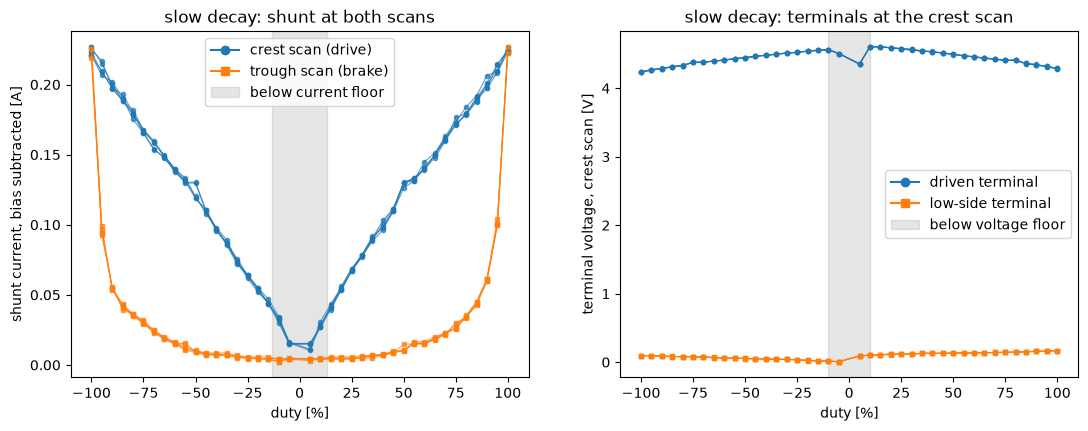

,valid_frac,crest_current_A,trough_offset_counts,driven_terminal_V,lowside_terminal_V
duty_pct,,,,,
-100.000000,0.999,0.223,249.057,4.239,0.097
-94.998016,0.999,0.211,106.557,4.268,0.093
-89.999084,0.999,0.199,61.157,4.289,0.088
-84.997101,0.999,0.190,46.557,4.315,0.083
-69.997253,0.999,0.157,26.757,4.380,0.074
-49.998474,0.999,0.124,10.757,4.446,0.054
-29.999695,0.999,0.074,6.757,4.515,0.040
-19.998779,0.999,0.054,5.357,4.543,0.024
-14.999847,0.999,0.045,5.157,4.555,0.018


In [4]:
def slow_steps(df):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        vA, vB = terms_V(seg)
        hi, lo = (vA, vB) if d > 0 else (vB, vA)   # driven and low-side terminal
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * CH.a_per_count,
            "trough_offset_counts": seg["current_trough"].median() - seg["bias"].iloc[0],
            "driven_terminal_V": np.median(hi),
            "lowside_terminal_V": np.median(lo),
        })
    return pd.DataFrame(out).sort_values("duty_pct")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, sweeps in recs.items():
    st = slow_steps(sweeps["slow"][0])
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["trough_offset_counts"] * CH.a_per_count, "-s", ms=3,
                 lw=0.8, color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["driven_terminal_V"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["lowside_terminal_V"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
axes[0].plot([], [], "-o", color="tab:blue", label="crest scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="trough scan (brake)")
axes[0].axvspan(-CH.floor_i_pct, CH.floor_i_pct, color="grey", alpha=0.2, label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title("slow decay: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "-o", color="tab:blue", label="driven terminal")
axes[1].plot([], [], "-s", color="tab:orange", label="low-side terminal")
axes[1].axvspan(-CH.floor_v_pct, CH.floor_v_pct, color="grey", alpha=0.2, label="below voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("terminal voltage, crest scan [V]")
axes[1].set_title("slow decay: terminals at the crest scan")
axes[1].legend()
plt.show()

# Pooled over recordings, by signed duty, at a few grid points per direction.
allst = pd.concat([slow_steps(s["slow"][0]) for s in recs.values()])
show = [5, 10, 15, 20, 30, 50, 70, 85, 90, 95, 100]
(allst[allst["mag_pct"].isin(show)]
      .groupby("duty_pct")[["valid_frac", "crest_current_A", "trough_offset_counts",
                            "driven_terminal_V", "lowside_terminal_V"]]
      .mean().round(3))

Findings for the drive state (crest scan):

- The shunt current rises with duty from the first step. The validity flag
  sets from the 15% step in every recording, the first grid point above
  the 13.3% floor. The current curve passes through the flag edge without
  a kink. At 100% duty the current is 0.22 A, against 0.32 A in the
  retired battery run. That is the rail (4.3 V here against 7.3 V) plus
  the larger shunt in the loop.
- The driven terminal reads the rail from the 10% step in both directions,
  4.61 V forward and 4.57 V reverse. At 5% terminal A reads a quarter volt
  low and terminal B 60 mV low, so on the 0.1 V criterion of section 5.4
  terminal A settles from 10% and terminal B from 5%. The 10% voltage
  floor covers both. The rail sags by about 0.3 V from 10% to 100% duty
  within a sweep (the battery run sagged 0.08 V), and moves by 2 mV from
  the first recording to the last (table in section 5.4).
- The low-side terminal rises with current, and the two terminals do not
  read alike. Terminal B, the low side of forward drive, reads 0.10 V at
  15% and 0.17 V at 100%. Terminal A, the low side of reverse drive, reads
  0.02 V and 0.10 V at the same steps. The slope against the shunt
  current is 0.23 Ohm on B and 0.41 Ohm on A (section 5.4), the
  on-resistance of the low-side switch plus the shunt. The retired run
  gave 0.30 Ohm pooled over both directions with the 33 mOhm shunt, so
  the mean of the two is in line with that plus the extra 27 mOhm. The
  driven terminal also reads about 40 mV higher on A than on B at the
  same duty. Divider tolerance (1% resistors, so about 1.4% on $r$, which
  is 65 mV at the rail) can explain a difference of that size at 4.6 V,
  but not 80 mV at 0.1 V. I have not chased it. It lives next to the rest
  split of notebook 00, section 5.3, as an open item on this chain.

Findings for the brake state (trough scan):

- The trough shunt sits 4 to 5 counts above the baseline bias at low duty
  in every recording, and the offset grows with duty, 13 counts at 50%,
  25 at 70%, 49 at 85% and 68 at 90%. It stays within 20 counts of the
  bias up to the 60% step. On the retired chain the offset was 3 counts
  at low duty and 8 at 85%, so it grows much faster on this chain, and I
  do not know why. In current terms 49 counts is 44 mA equivalent.
  *Hypothesis (not tested here): the offset is the amplifier still
  recovering from the drive pulse when the trough scan fires, and the
  larger shunt makes the pulse it has to recover from larger.*
- At 95% the trough reading climbs toward the drive current, and at 100%
  the two scans read the same value, because there is no OFF window
  left. This matches the 86.7% OFF-window floor from section 2.
- The 4 to 5 count floor of the offset shows up again in the fast-decay
  coast window (section 5.3) and in the spin-down brake and coast
  segments (section 5.4). Every OFF-state shunt sample sits about 5
  counts (4.5 mA equivalent) above the bridge-disabled baseline. The
  retired chain showed 3 counts. So a live bias tracker that runs while
  the bridge is enabled will settle 5 counts above the baseline of
  section 3, which is fine as long as the drive current is referenced to
  the same tracker.

The brake state's terminal voltages come from the spin-down sweep in
section 6. Both terminals sit within 0.02 V of ground for the whole
brake segment, which puts their taps near two thirds of the bias (table
in section 5.4).

### 5.3 Fast decay

Under fast decay the trough scan reads the drive state and the crest scan
reads the coast state. The left panel shows the shunt at both scans. The
right panel shows the sum of the two crest-scan terminals, $v_A + v_B$,
which serves as the phase discriminator of the coast window. At rest both
terminals read their own bias, so the sum's baseline is $V_{B,A} +
V_{B,B}$, about 1.25 V. A floating terminal cannot exceed the rail. A
terminal reading above it is being held there by a conducting high-side
body diode, which means winding current is still flowing, and the sum
then exceeds the rail as well, since the other terminal cannot fall below
its clamp. The measured rail (section 5.2) is drawn as the discriminator
threshold. The table also lists the terminal driven high and the terminal
driven low separately.

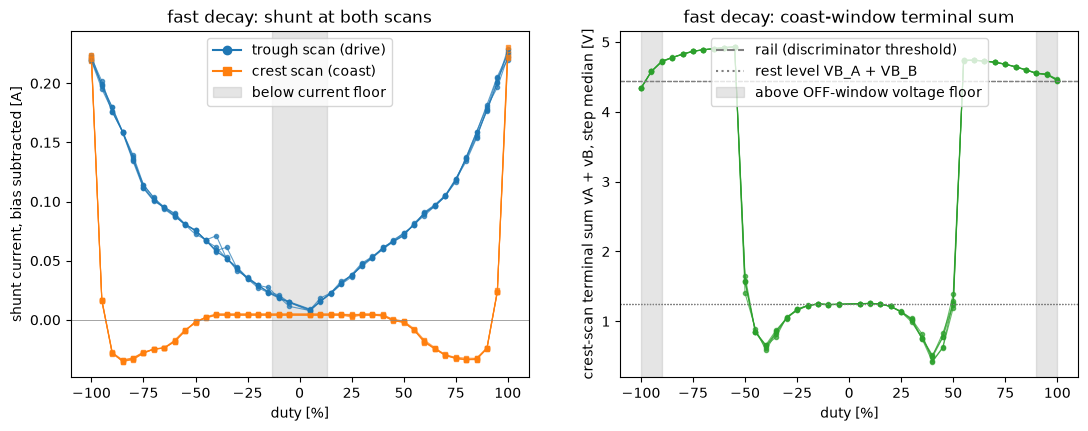

,valid_frac,trough_current_A,crest_current_A,high_terminal_V,low_terminal_V,sum_median_V,diode_frac,travel_mV
mag_pct,,,,,,,,
5,0.000,0.011,0.004,0.617,0.631,1.247,0.000,-20.907
10,0.000,0.018,0.004,0.595,0.653,1.248,0.000,-0.363
15,0.999,0.023,0.004,0.571,0.676,1.248,0.000,-0.927
20,0.999,0.030,0.004,0.521,0.697,1.218,0.000,-0.201
25,0.999,0.036,0.004,0.430,0.720,1.150,0.000,0.524
30,0.999,0.045,0.004,0.297,0.738,1.035,0.000,1.732
35,0.999,0.053,0.004,0.045,0.758,0.803,0.000,0.000
40,0.999,0.061,0.004,-0.250,0.802,0.551,0.000,20.907
45,0.999,0.067,0.001,-0.427,1.217,0.789,0.000,57.041


In [5]:
def rail_V(sweeps):
    # Supply rail per recording: median driven terminal over the valid
    # slow-decay drive steps at 20% and above, each terminal with its own
    # rest bias. On the USB supply the rail sags with duty, so this is a
    # mid-range figure, used only as the diode-phase threshold.
    df = sweeps["slow"][0]
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1) & (df["mag_pct"] >= 20)]
    vA, vB = terms_V(v)
    return float(np.median(np.where(v["duty_pct"] > 0, vA, vB)))

def fast_steps(df, rail):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        vA, vB = terms_V(seg)
        hi, lo = (vA, vB) if d > 0 else (vB, vA)   # terminal driven high, driven low
        ssum = vA + vB
        p = seg["pos"].to_numpy() * CH.v_adc_per_count
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "trough_current_A": (seg["current_trough"].median() - seg["bias"].iloc[0]) * CH.a_per_count,
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * CH.a_per_count,
            "high_terminal_V": np.median(hi),
            "low_terminal_V": np.median(lo),
            "sum_median_V": np.median(ssum),
            "diode_frac": (ssum > rail).mean(),
            "travel_mV": (np.median(p[-20:]) - np.median(p[:20])) * 1e3 * np.sign(d),
        })
    return pd.DataFrame(out).sort_values("duty_pct")

rails = {name: rail_V(sweeps) for name, sweeps in recs.items()}
# rest level of the terminal sum: VB_A + VB_B, each from its own tap
rest_sum = {name: (sweeps["slow"][0]["vb"].iloc[0] + sweeps["slow"][0]["vb_b"].iloc[0])
            * CH.v_adc_per_count for name, sweeps in recs.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, sweeps in recs.items():
    st = fast_steps(sweeps["fast"][0], rails[name])
    axes[0].plot(st["duty_pct"], st["trough_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["sum_median_V"], "-o", ms=3, lw=0.8,
                 color="tab:green", alpha=0.7)
    axes[1].axhline(rails[name], color="grey", lw=0.8, ls="--")
    axes[1].axhline(rest_sum[name], color="grey", lw=0.8, ls=":")
axes[0].plot([], [], "-o", color="tab:blue", label="trough scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="crest scan (coast)")
axes[0].axhline(0, color="grey", lw=0.5)
axes[0].axvspan(-CH.floor_i_pct, CH.floor_i_pct, color="grey", alpha=0.2, label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title("fast decay: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "--", color="grey", label="rail (discriminator threshold)")
axes[1].plot([], [], ":", color="grey", label="rest level VB_A + VB_B")
axes[1].axvspan(-100, -(100 - CH.floor_v_pct), color="grey", alpha=0.2)
axes[1].axvspan(100 - CH.floor_v_pct, 100, color="grey", alpha=0.2,
                label="above OFF-window voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("crest-scan terminal sum vA + vB, step median [V]")
axes[1].set_title("fast decay: coast-window terminal sum")
axes[1].legend(loc="upper center")
plt.show()

allft = pd.concat([fast_steps(s["fast"][0], rails[n]) for n, s in recs.items()])
(allft.groupby("mag_pct")[["valid_frac", "trough_current_A", "crest_current_A",
                            "high_terminal_V", "low_terminal_V", "sum_median_V",
                            "diode_frac", "travel_mV"]]
      .mean().round(3))

Findings for the drive state (trough scan):

- The trough shunt reads the drive current, rising monotonically from 5%
  to 100%, and the validity flag sets from the 15% step as under slow
  decay. The same floor applies to both decay modes.

Findings for the coast state (crest scan), by duty range:

- **5% to 35%.** The crest shunt reads the bias plus the 4-count
  OFF-state offset of section 5.2. Both terminals sit near the bias. The
  terminal driven low reads 0.63 to 0.76 V, a little above it, and the
  terminal driven high drifts below it as duty grows, from 0.62 V at 5%
  to 0.30 V at 30% and 0.05 V at 35%. The position column shows no net
  motion up to 35%. In the retired run the servo moved from 30%, and the
  shift is the rail. 35% of 4.6 V is 1.6 V, against 2.6 V for 35% of
  7.3 V. *Hypothesis (not tested here): the drive pulse is too short for
  the current to build against the winding inductance, so conduction is
  discontinuous and the average torque falls below the friction
  threshold.*
- **55% to 95%.** The terminal driven low sits at 5.29 V, one diode drop
  (0.86 V) above the rail, in most samples of each step, and the terminal
  driven high at -0.52 V, one body-diode drop below ground. This is the
  diode phase. Winding current is still flowing when the scan fires,
  returning through the high-side body diode of the terminal that was
  driven low and the low-side body diode of the terminal that was driven
  high, and both drops are now readable. The crest shunt reads below the
  bias in the same range, the freewheel current crossing the shunt
  backward, growing from 0.01 A at 55% to 0.034 A at 85%. In the retired
  run the diode phase ran from 60% to 85% with the 55% step mixed, the
  drops were 0.93 V and -0.58 V, and the freewheel current was three
  times larger, 0.05 to 0.09 A, at the higher rail.
- **40% to 50%.** The terminal driven high reaches the clamp level,
  -0.25 V at 40% and -0.43 V at 45%, while the terminal driven low rises
  steeply from 0.80 V to 1.85 V. No sample is above the rail up to 45%,
  and one eighth of the 50% step is. The next code cell examines what
  this reading is.
- **90% to 100%.** The OFF window shrinks toward the terminal slots'
  offset from the crest. On this chain, with the faster ADC, the diode
  level still holds in 81% of the samples at 90% and 72% at 95%, in both
  directions, so the map in section 5.4 runs the diode phase to 95% with
  those two steps partly mixed. The configured 90% OFF-window voltage
  floor is the conservative edge. On the retired chain the 90% step was
  already fully mixed, one terminal at the diode level and the other at
  the drive level. At 100% both scans read the drive state.

The terminal reading in the 40% to 50% range needs a closer look. If it
were the back-EMF of a spinning motor, it would grow with speed within a
step as the motor accelerates, and it would put the terminal driven high
above the terminal driven low, the polarity the coast segments of section
6.1 show. The figure follows one step at 45% duty through its 80 ms, next
to a 60% step in the diode phase.

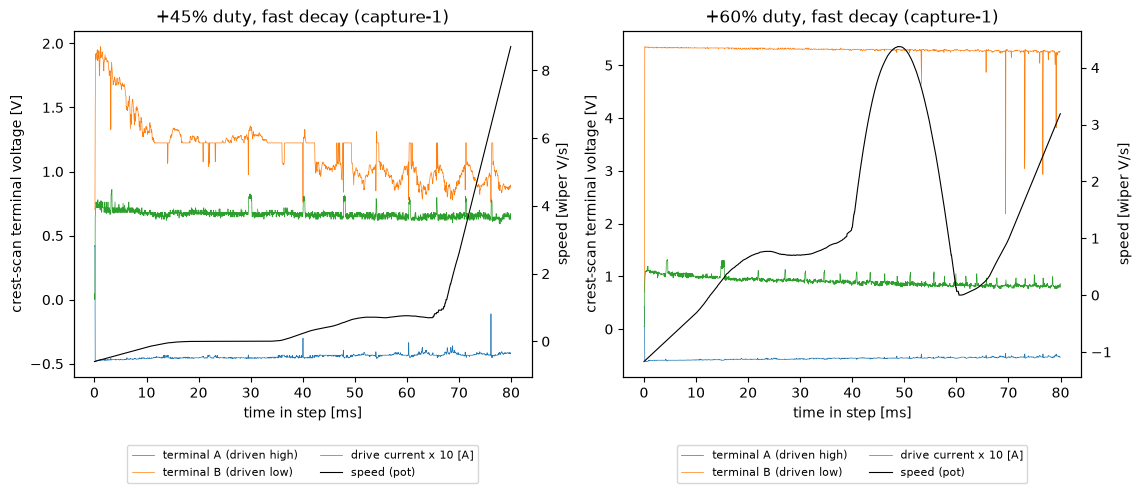

,speed_Vps,terminal_B_V,terminal_A_V,drive_current_A
quarter,,,,
1,0.003,1.318,-0.457,0.068
2,0.228,1.282,-0.452,0.067
3,1.599,1.083,-0.438,0.066
4,1.435,0.955,-0.429,0.065


In [6]:
name, sweeps = next(iter(recs.items()))
df = sweeps["fast"][0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, pct in zip(axes, [45, 60]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (TICK_HZ / 1000)
    p = seg["pos"].to_numpy() * CH.v_adc_per_count
    speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / TICK_HZ)
    vA, vB = terms_V(seg)
    ax.plot(t, vA, lw=0.5, label="terminal A (driven high)")
    ax.plot(t, vB, lw=0.5, label="terminal B (driven low)")
    ax.plot(t, (seg["current_trough"] - seg["bias"]) * CH.a_per_count * 10, lw=0.5,
            label="drive current x 10 [A]")
    ax.set_xlabel("time in step [ms]")
    ax.set_ylabel("crest-scan terminal voltage [V]")
    ax2 = ax.twinx()
    ax2.plot(t, speed, color="k", lw=0.8, label="speed (pot)")
    ax2.set_ylabel("speed [wiper V/s]")
    ax.set_title(f"+{pct}% duty, fast decay ({name})")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=2, fontsize=8)
plt.show()

# Quarter-by-quarter means of the +45% step, every recording.
rows = []
for name, sweeps in recs.items():
    seg = sweeps["fast"][0]
    seg = seg[np.isclose(seg["duty_pct"], 45, atol=0.5)]
    p = seg["pos"].to_numpy() * CH.v_adc_per_count
    speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / TICK_HZ)
    vA, vB = terms_V(seg)
    n = len(seg) // 4
    for q in range(4):
        sl = slice(q * n, (q + 1) * n)
        rows.append({
            "recording": name,
            "quarter": q + 1,
            "speed_Vps": speed[sl].mean(),
            "terminal_B_V": np.median(vB[sl]),
            "terminal_A_V": np.median(vA[sl]),
            "drive_current_A": (seg["current_trough"].iloc[sl].median()
                                - seg["bias"].iloc[0]) * CH.a_per_count,
        })
pd.DataFrame(rows).groupby("quarter")[["speed_Vps", "terminal_B_V", "terminal_A_V",
                                        "drive_current_A"]].mean().round(3)

Within the 45% step the reading on terminal B starts near 1.9 V and
falls to about 1.2 V within the first 10 ms, while the motor is still at
rest. It then sits there until the speed picks up in the last quarter of
the step and ends near 0.9 V. Per quarter the medians are 1.32, 1.28,
1.08 and 0.96 V against speeds of 0, 0.2, 1.6 and 1.4 wiper V/s, and the
drive current falls slightly as the motor speeds up. Terminal A, the
terminal driven high, sits at the clamp level of -0.45 V throughout. In
the 60% panel the diode level of 5.3 V holds flat while the speed swings
between 0 and 4 wiper V/s. In the coast segments of section 6.1 the
back-EMF puts the terminal driven high above the other and grows with
speed. The fast-decay crest reading has the opposite polarity and the
opposite speed dependence, and it is present at 10% to 35% where the
motor does not move at all. It is therefore a residue of the diode phase
and carries no speed information. *Hypothesis (not tested here): after
the diode current dies, the terminal that was held at rail plus one diode
drop discharges toward the bias through its 10.1 kOhm divider and the
capacitance of the output node, and the scan catches it part way down,
while a small remaining current holds the other terminal at its
body-diode clamp. The reading grows with duty because a larger current
lengthens the diode phase and leaves less time for the discharge before
the fixed scan instant. On the retired chain the same step read 2.3 V
falling to 0.9 V, and the higher rail and the three times slower
discharge through its 30 kOhm dividers both fit this picture.*

The consequence for the series is that the fast-decay crest scan delivers
no direct back-EMF sample at any duty in this scan geometry. Direct
back-EMF is available from the coast segments of the spin-down sweep
(section 6.1), where the scan sits hundreds of microseconds after the
current has died.

### 5.4 Validity map

The map below records, for every bridge state and scan, the duty range in
which each channel reads a settled value of that state. The ranges come
from the data of every recording, on the 5% grid of the sweeps. The
data-derived edges are computed first, then assembled with the configured
floors of section 2. A driven terminal counts as settled when it reads
within 0.1 V of the same direction's light-load level (the 10% to 30%
steps), since the USB rail sags with duty and a fixed fraction of the
rail would not tell a settled sample from a sagging one.

In [7]:
SETTLED_V = 0.1     # a driven terminal counts as settled within this of its light-load level
EMF_HI_V = 1.1      # the top of the coast EMF range reached at this rail (section 6.1)

def edges(name, sweeps):
    rail = rails[name]
    slow = sweeps["slow"][0]
    fast = sweeps["fast"][0]
    st = slow_steps(slow)
    ft = fast_steps(fast, rail)
    fwd, rev = st[st["duty_pct"] > 0], st[st["duty_pct"] < 0]
    e = {"recording": name}
    e["flag_from_pct"] = int(st[st["valid_frac"] > 0.5]["mag_pct"].min())
    # Driven terminal settled: within SETTLED_V of the direction's light-load
    # level (the 10% to 30% steps), since the USB rail sags with duty.
    for tab, key in [(fwd, "terminal_A_from_pct"), (rev, "terminal_B_from_pct")]:
        light = tab[(tab["mag_pct"] >= 10) & (tab["mag_pct"] <= 30)]["driven_terminal_V"].mean()
        e[key] = int(tab[tab["driven_terminal_V"] > light - SETTLED_V]["mag_pct"].min())
    def both_dirs(tab, cond):
        # Grid points where the condition holds in both directions.
        ok = tab[cond].groupby("mag_pct").size() == 2
        return set(ok[ok].index)
    def run_up_from(ok, start):
        # Last grid point of the contiguous run that starts at `start`.
        pct = start
        while pct + 5 in ok:
            pct += 5
        return pct
    ok = both_dirs(st, st["trough_offset_counts"].abs() <= 20)
    e["trough_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["crest_current_A"].abs() <= 10 * CH.a_per_count)
    e["fast_crest_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["diode_frac"] >= 0.5)
    e["diode_phase_from_pct"] = min(ok)
    e["diode_phase_to_pct"] = run_up_from(ok, min(ok))
    e["rail_V"] = rail
    e["VB_A_V"] = slow["vb"].iloc[0] * CH.v_adc_per_count
    e["VB_B_V"] = slow["vb_b"].iloc[0] * CH.v_adc_per_count
    # low-side on-resistance plus shunt, per terminal: B is the low side
    # when driving forward, A in reverse
    for tab, key in [(fwd, "lowside_R_B_ohm"), (rev, "lowside_R_A_ohm")]:
        ok = tab[(tab["mag_pct"] >= 20) & (tab["mag_pct"] <= 85)]
        e[key] = np.polyfit(ok["crest_current_A"], ok["lowside_terminal_V"], 1)[0]
    dl = ft[(ft["mag_pct"] >= e["diode_phase_from_pct"]) & (ft["mag_pct"] <= e["diode_phase_to_pct"])]
    e["diode_low_terminal_V"] = dl["low_terminal_V"].median()
    e["diode_high_terminal_V"] = dl["high_terminal_V"].median()
    # brake terminals, from the spin-down brake segments
    sp = sweeps["spindown"][0]
    br = sp[sp["kind"] == "brake"]
    vA, vB = terms_V(br)
    e["brake_terminal_max_V"] = max(np.quantile(vA, 0.99), np.quantile(vB, 0.99))
    e["brake_shunt_offset_counts"] = br["current_raw"].median() - sp["bias"].iloc[0]
    # coast, from the spin-down coast segments: the negative terminal at
    # the top of the EMF range this rail reaches
    co = sp[sp["kind"] == "coast"]
    d = co["dir"].to_numpy()
    vA, vB = terms_V(co)
    emf = (vA - vB) * d
    e["coast_neg_terminal_hi_V"] = np.median(np.where(d > 0, vB, vA)[emf > EMF_HI_V])
    return e

edge_tab = pd.DataFrame([edges(n, s) for n, s in recs.items()]).set_index("recording")
edge_tab.round(3)

,flag_from_pct,terminal_A_from_pct,terminal_B_from_pct,trough_bias_to_pct,fast_crest_bias_to_pct,diode_phase_from_pct,diode_phase_to_pct,rail_V,VB_A_V,VB_B_V,lowside_R_B_ohm,lowside_R_A_ohm,diode_low_terminal_V,diode_high_terminal_V,brake_terminal_max_V,brake_shunt_offset_counts,coast_neg_terminal_hi_V
recording,,,,,,,,,,,,,,,,,
capture-1,15,10,5,60,55,55,95,4.437,0.617,0.632,0.232,0.404,5.293,-0.525,0.013,4.833,-0.382
capture-2,15,10,5,60,55,55,95,4.437,0.617,0.632,0.231,0.417,5.292,-0.519,0.013,4.842,-0.384
capture-3,15,10,5,60,50,55,95,4.437,0.617,0.632,0.228,0.433,5.292,-0.512,0.013,5.051,-0.384
capture-4,15,10,5,60,50,55,95,4.439,0.617,0.632,0.271,0.405,5.293,-0.522,0.013,4.318,-0.382
capture-5,15,10,5,60,50,55,95,4.439,0.617,0.632,0.231,0.408,5.293,-0.522,0.013,4.333,-0.384


In [8]:
# Conservative over recordings: latest lower edge, earliest upper edge.
def as_edges(s):
    return {k: (int(v) if k.endswith("_pct") else v) for k, v in s.items()}
lo = as_edges(edge_tab.max())
hi = as_edges(edge_tab.min())
mid = edge_tab.mean()
rows = [
    ("drive", "slow", "crest", "shunt",
     f">= {CH.floor_i_pct:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("drive", "slow", "crest", "driven terminal",
     f">= {CH.floor_v_pct:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     "supply rail minus the high-side drop", "supply estimate"),
    ("drive", "slow", "crest", "low-side terminal",
     f">= {CH.floor_v_pct:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     f"current times low-side on-resistance plus shunt, about {mid['lowside_R_A_ohm']:.2f} Ohm on A, "
     f"{mid['lowside_R_B_ohm']:.2f} Ohm on B", "switch drop"),
    ("drive", "fast", "trough", "shunt",
     f">= {CH.floor_i_pct:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("brake", "slow", "trough", "shunt",
     f"<= {100 - CH.floor_i_pct:.1f}", f"within 20 counts of bias to {hi['trough_bias_to_pct']}%",
     "bias plus a recovery offset growing with duty", "live bias tracker"),
    ("brake", "spin-down segment", "crest", "both terminals",
     "any", f"below {lo['brake_terminal_max_V']:.2f} V in all samples (tap near two thirds of VB)",
     "near ground, winding shorted through the low-side switches", "state check"),
    ("brake", "spin-down segment", "crest", "shunt",
     "any", f"offset {lo['brake_shunt_offset_counts']:.0f} counts",
     "bias, no current through the shunt", "bias"),
    ("coast", "fast", "crest", "shunt",
     f"<= {100 - CH.floor_i_pct:.1f}", f"within 10 counts of bias to {hi['fast_crest_bias_to_pct']}%",
     "bias where the current has died, negative freewheel current in the diode phase", "bias, diode current"),
    ("coast", "fast", "crest", "terminals, diode phase",
     f"<= {100 - CH.floor_v_pct:.1f}", f"sum above rail: {lo['diode_phase_from_pct']}% to {hi['diode_phase_to_pct']}%",
     f"rail plus one diode drop ({mid['diode_low_terminal_V'] - mid['rail_V']:.2f} V) on the terminal driven low, "
     f"{mid['diode_high_terminal_V']:.2f} V on the other",
     "phase discriminator only"),
    ("coast", "fast", "crest", "terminals, sum below rail",
     f"<= {100 - CH.floor_v_pct:.1f}", f"5% to {lo['diode_phase_from_pct'] - 10}%, {lo['diode_phase_from_pct'] - 5}% mixed",
     "diode-phase residue on the terminal driven low, the other clamped, unrelated to speed", "none"),
    ("coast", "spin-down segment", "crest", "vA - vB",
     "any", "from the fourth sample after the drive ends, sum below rail",
     "direct back-EMF, each terminal on its own rest bias (section 6.1)", "speed"),
    ("coast", "spin-down segment", "crest", "negative terminal",
     "any", f"{mid['coast_neg_terminal_hi_V']:.2f} V at the highest EMF reached here (above {EMF_HI_V} V)",
     "falls with the EMF, the body-diode clamp is not reached at this rail (section 6.1)", "state check"),
    ("coast", "spin-down segment", "crest", "shunt",
     "any", "from the fourth sample after the drive ends",
     "bias, no current through the shunt", "bias"),
]
validity_map = pd.DataFrame(rows, columns=[
    "state", "decay or segment", "scan", "channel", "configured duty [%]",
    "measured range", "reads", "use in later notebooks"]).set_index(["state", "decay or segment", "scan", "channel"])
pd.set_option("display.max_colwidth", 100)
validity_map

configured duty [%]  \
state decay or segment  scan   channel                                         
drive slow              crest  shunt                                 >= 13.3   
                               driven terminal                       >= 10.0   
                               low-side terminal                     >= 10.0   
      fast              trough shunt                                 >= 13.3   
brake slow              trough shunt                                 <= 86.7   
      spin-down segment crest  both terminals                            any   
                               shunt                                     any   
coast fast              crest  shunt                                 <= 86.7   
                               terminals, diode phase                <= 90.0   
                               terminals, sum below rail             <= 90.0   
      spin-down segment crest  vA - vB                                   any   
                               negative terminal                         any   
                               shunt                                     any   

                                                                                                       measured range  \
state decay or segment  scan   channel                                                                                  
drive slow              crest  shunt                                                                    flag from 15%   
                               driven terminal                                                  A from 10%, B from 5%   
                               low-side terminal                                                A from 10%, B from 5%   
      fast              trough shunt                                                                    flag from 15%   
brake slow              trough shunt                                                  within 20 counts of bias to 60%   
      spin-down segment crest  both terminals                 below 0.01 V in all samples (tap near two thirds of VB)   
                               shunt                                                                  offset 5 counts   
coast fast              crest  shunt                                                  within 10 counts of bias to 50%   
                               terminals, diode phase                                      sum above rail: 55% to 95%   
                               terminals, sum below rail                                         5% to 45%, 50% mixed   
      spin-down segment crest  vA - vB                    from the fourth sample after the drive ends, sum below rail   
                               negative terminal                -0.38 V at the highest EMF reached here (above 1.1 V)   
                               shunt                                      from the fourth sample after the drive ends   

                                                                                                                                          reads  \
state decay or segment  scan   channel                                                                                                            
drive slow              crest  shunt                                                                                    drive current plus bias   
                               driven terminal                                                             supply rail minus the high-side drop   
                               low-side terminal            current times low-side on-resistance plus shunt, about 0.41 Ohm on A, 0.24 Ohm on B   
      fast              trough shunt                                                                                    drive current plus bias   
brake slow              trough shunt                                                              bias plus a recovery offset growing with duty   
      spin-

The measured edges agree with the configured floors on the 5% grid in
every recording, with one thing to note on the coast side. The
diode-phase range reaches the 95% step, past the 90% OFF-window voltage
floor, in about three quarters of the samples. The configured floor is
the conservative edge and stays. In corrected units, with each terminal
taken as $r\,\text{tap} - (r - 1) V_B$ on its own rest reading, the sum
$v_A + v_B$ rests at $V_{B,A} + V_{B,B}$ and exceeds the rail only in
the diode phase, which is the discriminator rule the later notebooks
apply.

## 6. Spin-down

The spin-down sweep enters each coast or brake segment at the speed the
preceding 80 ms drive step reached. Entry speeds range from about 1.5 to
4.9 wiper V/s and vary from step to step (section 3), so coast and brake
are compared through fitted models against measured speed, never by
pairing segments. The retired battery run entered at 2 to 10 wiper V/s.
The same 20%, 30% and 40% steps reach half the speed at this rail, so
every speed, travel and EMF below is smaller than in that run for the
supply alone.

### 6.1 Terminal voltages during coast as direct back-EMF

During a coast segment the bridge is off, so once the winding current has
died the terminals carry the motor's back-EMF. The difference $v_A -
v_B$, each terminal on its own rest reading, reads the EMF directly, $e =
r\,(\text{tap}_A - \text{tap}_B)$ minus the rest split in ADC volts,
taken positive along the entry direction. Both terminals are readable.
How the EMF divides between the two terminals is a measured thing, and
the table further down shows it. The first three samples after the drive
ends are excluded (the diode phase appears in the second or third sample,
with the sum above the rail, and the third can catch the transition out
of it), and any later sample with the sum above the rail is excluded the
same way.

The figure plots the EMF against the pot-derived speed for every coast
segment of every recording. Both signals are smoothed with the same
20 ms window. The second panel shows one coast segment against time,
with both terminals.

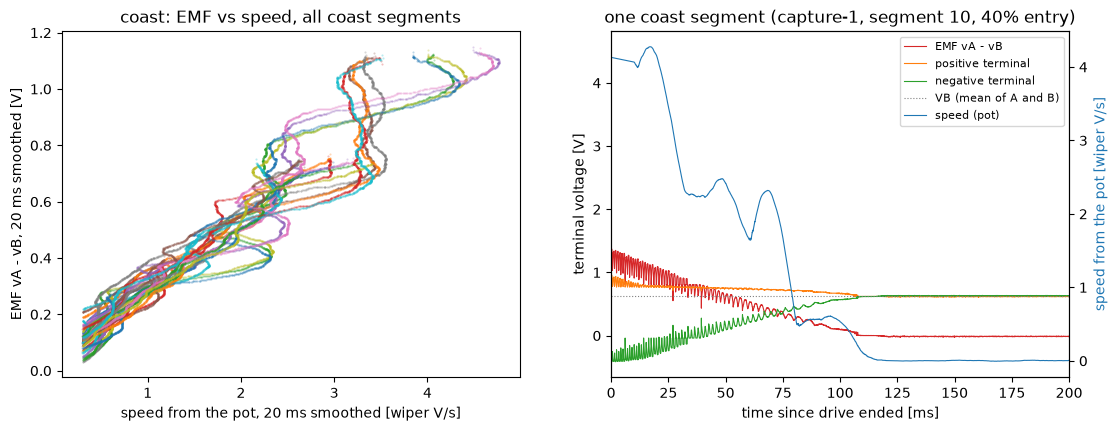

,slope_regression_s,intercept_V,slope_integral_s,segments
mean,0.2401,0.0564,0.2738,6.0
min,0.2364,0.0441,0.2698,6.0
max,0.2447,0.0679,0.2769,6.0
count,5.0000,5.0000,5.0000,5.0


In [9]:
SG_WIN = 401   # 20 ms smoothing window for speed from the pot

SKIP = 3       # samples excluded at the start of every coast segment

def coast_segments(sweeps):
    # Per coast segment: time, position (wiper V, positive along the entry
    # direction), EMF vA - vB (positive along the entry direction), the
    # positive and negative terminals and their sum, all in V. Each
    # terminal is corrected with its own rest bias.
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vA, vB = terms_V(seg)
        out.append({
            "seg": seg_id,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "t": np.arange(len(seg)) / TICK_HZ,
            "p": seg["pos"].to_numpy() * d * CH.v_adc_per_count,
            "e": (vA - vB) * d,
            "pos_t": vA if d > 0 else vB,
            "neg_t": vB if d > 0 else vA,
            "sum": vA + vB,
            "shunt_offset": seg["current_raw"].to_numpy() - seg["bias"].iloc[0],
        })
    return out

def coast_mask(c, rail):
    i = np.arange(len(c["e"]))
    return (i >= SKIP) & (c["sum"] < rail)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pts = []
for name, sweeps in recs.items():
    for c in coast_segments(sweeps):
        v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
        es = savgol_filter(c["e"], SG_WIN, 2)
        i = np.arange(len(v))
        m = (i >= SG_WIN // 2) & (v > 0.3) & coast_mask(c, rails[name])
        axes[0].plot(v[m], es[m], ".", ms=1, alpha=0.3)
        pts.append(pd.DataFrame({"recording": name, "seg": c["seg"], "v": v[m], "e": es[m]}))
axes[0].set_xlabel("speed from the pot, 20 ms smoothed [wiper V/s]")
axes[0].set_ylabel("EMF vA - vB, 20 ms smoothed [V]")
axes[0].set_title("coast: EMF vs speed, all coast segments")
name, sweeps = next(iter(recs.items()))
c = coast_segments(sweeps)[2]
v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
axes[1].plot(c["t"] * 1e3, c["e"], lw=0.8, color="tab:red", label="EMF vA - vB")
axes[1].plot(c["t"] * 1e3, c["pos_t"], lw=0.8, color="tab:orange", label="positive terminal")
axes[1].plot(c["t"] * 1e3, c["neg_t"], lw=0.8, color="tab:green", label="negative terminal")
axes[1].axhline(rest_sum[name] / 2, color="grey", lw=0.8, ls=":", label="VB (mean of A and B)")
axes[1].set_xlabel("time since drive ended [ms]")
axes[1].set_ylabel("terminal voltage [V]")
ax2 = axes[1].twinx()
ax2.plot(c["t"] * 1e3, v, lw=0.8, color="tab:blue", label="speed (pot)")
ax2.set_ylabel("speed from the pot [wiper V/s]", color="tab:blue")
axes[1].set_xlim(0, 200)
axes[1].set_title(f"one coast segment ({name}, segment {c['seg']}, {c['entry_pct']}% entry)")
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
plt.show()

pts = pd.concat(pts)
rows = []
ratio_rows = []
for name, g in pts.groupby("recording"):
    k = np.polyfit(g["v"], g["e"], 1)
    # Ripple-immune route: the integral of the EMF over the segment divided
    # by the travel is the slope, if E = k v. The recording's slope is the
    # sum of the integrals over the sum of the travels, so a segment counts
    # in proportion to how far it moved.
    integrals, travels = [], []
    for c in coast_segments(recs[name]):
        m = coast_mask(c, rails[name])
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:3])
        integrals.append(np.sum(c["e"][m]) / TICK_HZ)
        travels.append(travel)
        ratio_rows.append({"recording": name, "entry_pct": c["entry_pct"],
                           "ratio": integrals[-1] / travel,
                           "travel_V": travel, "emf_peak_V": c["e"][m].max()})
    rows.append({"recording": name, "slope_regression_s": k[0], "intercept_V": k[1],
                 "slope_integral_s": np.sum(integrals) / np.sum(travels), "segments": len(travels)})
bemf_fit = pd.DataFrame(rows).set_index("recording")
bemf_fit.agg(["mean", "min", "max", "count"]).round(4)

The integral ratio per segment, grouped by the duty of the drive step
that set the entry speed, tests whether the slope depends on speed. The
travel and the peak EMF of each group say how far each segment moved and
how high its EMF got:

In [10]:
(pd.DataFrame(ratio_rows).groupby("entry_pct")[["ratio", "travel_V", "emf_peak_V"]]
   .agg(["mean", "std", "min", "max"]).round(4))

ratio                         travel_V                          \
             mean     std     min     max     mean     std     min     max   
entry_pct                                                                    
20         0.2882  0.1143  0.1653  0.4103   0.0387  0.0044  0.0314  0.0467   
30         0.2680  0.0145  0.2494  0.2858   0.1248  0.0125  0.1039  0.1386   
40         0.2728  0.0208  0.2499  0.3015   0.2348  0.0040  0.2272  0.2393   

          emf_peak_V                          
                mean     std     min     max  
entry_pct                                     
20            0.5304  0.0113  0.5107  0.5471  
30            0.9558  0.0134  0.9299  0.9792  
40            1.3621  0.0133  1.3362  1.3787

The two terminals against the EMF level, pooled over every coast segment
of every recording and masked like the fits. This is where the EMF split
between the terminals is measured:

In [11]:
# Both terminals against the EMF level, pooled over every coast segment of
# every recording, masked like the fits. Bins of 0.2 V.
rows = []
for name, sweeps in recs.items():
    for c in coast_segments(sweeps):
        m = coast_mask(c, rails[name])
        rows.append(pd.DataFrame({"e": c["e"][m], "pos_t": c["pos_t"][m],
                                  "neg_t": c["neg_t"][m], "sum": c["sum"][m]}))
tt = pd.concat(rows)
tt["EMF bin [V]"] = (np.floor(tt["e"] / 0.2) * 0.2).round(1)
(tt.groupby("EMF bin [V]")[["pos_t", "neg_t", "sum"]]
   .median().rename(columns={"pos_t": "positive terminal [V]", "neg_t": "negative terminal [V]",
                             "sum": "sum vA + vB [V]"})
   .assign(samples=tt.groupby("EMF bin [V]").size()).round(3))

,positive terminal [V],negative terminal [V],sum vA + vB [V],samples
EMF bin [V],,,,
-0.2,0.617,0.632,1.249,96657
0.0,0.632,0.617,1.249,107751
0.2,0.713,0.415,1.125,12020
0.4,0.733,0.247,0.980,8752
0.6,0.750,0.048,0.795,7278
0.8,0.763,-0.140,0.622,3837
1.0,0.780,-0.315,0.457,2523
1.2,0.856,-0.406,0.455,1092


Findings:

- The EMF follows the speed with a slope of 0.274 V per wiper V/s from
  the travel-weighted integral ratio (0.270 to 0.277 across recordings)
  and 0.24 from the regression (0.236 to 0.245), with an intercept of
  0.06 V from the regression. The regression is the weaker of the two.
  The pot ripple is noise on its speed axis, and noise on the x axis of
  a straight-line fit pulls the slope down and pushes the intercept up.
  That bites harder now that the speed range is half of the retired
  run's, where the two routes agreed within 4%. The integral ratio has
  no speed axis and is the one used below.
- By entry duty, the integral ratio is 0.268 for the 30% entries with a
  standard deviation of 0.015 over the ten segments, and 0.273 with a
  standard deviation of 0.021 for the 40% entries. The 20% entries
  scatter from 0.17 to 0.41. Their travel is 0.04 wiper V, under one
  period of the pot ripple below, so the denominator of the ratio is at
  the mercy of where in the ripple the segment starts and ends. The 30%
  and 40% entries travel 0.12 and 0.23 V, two to five ripple periods,
  and still scatter four times more than the retired run's 0.36 and
  0.64 V segments did. The travel-weighted ratio lets the long segments
  dominate.
- The retired run gave 0.29 on chain 2. The 5% difference is within
  what 1% resistors on two design-value divider ratios can produce, and
  the slope is a property of the motor and gear train as seen through
  the pot, with no rail in it, so I read the difference as chain, not
  motor. Which chain is closer to the truth needs a measured divider
  ratio, which neither has.
- The negative terminal carries nearly the whole EMF. In the binned table
  it falls by about 1 V per volt of EMF, from the bias at rest to -0.32 V
  in the 1.0 V bin, while the positive terminal rises only 0.15 V over
  the same range, and the sum falls with the EMF. Above 1.2 V the
  negative terminal flattens at -0.41 V and the sum stops falling, which
  is the body-diode clamp starting to conduct. The highest EMF at this
  rail is 1.38 V, so the clamp is only just reached here, in the last
  thousand samples of the table. The retired run reached 2.4 V of EMF
  and sat on the clamp at -0.47 V through most of every segment. The
  split is not the symmetric one that two equal dividers to one bias
  node would give. *Hypothesis (not tested here): some path in the gate
  driver, the bootstrap charging circuit being one candidate, holds the
  terminal that was driven high near the bias, so the other terminal
  takes the EMF.* The EMF is the terminal difference and does not depend
  on the split.
- The EMF decays smoothly through the segment, with a ripple of its own
  of about 9% rms at a period much shorter than the pot's. The
  pot-derived speed rides on a ripple of 10 to 20% rms with a period of
  roughly 0.05 V of wiper travel, visible in the right panel and as the
  loops in the left panel. That ripple is absent from the EMF, so it is
  on the pot side of the gear train. *Hypothesis (not tested here): the
  ripple is a periodic error of the potentiometer track or of the final
  gear stage. Notebook 06 takes it up.*
- The terminal difference removes the divider bias and the split, so
  neither the load of the dividers nor the clamp enters the slope.
  Notebook 03 compares this slope with the drive-side estimate. The
  motor-shaft constant needs the gear ratio (notebook 06).

The slope from the travel-weighted integral ratio is the one used below
to convert EMF volts into wiper V/s.

### 6.2 Coast deceleration vs speed

The model is Coulomb plus viscous friction,

$$\frac{dv}{dt} = -(a + b\,v), \qquad v > 0,$$

with $a$ in wiper V/s$^2$ and $b$ in 1/s. Two routes fit it. The pot
route fits the closed-form trajectory $p(t)$ of the model to the position
trace of every coast segment of a recording jointly, with one $(a, b)$
per recording and one entry speed per segment. The terminal route fits the
same model to the EMF $e(t)$ of the same segments, where $e$ stands in
for speed, and converts $a$ with the slope of section 6.1. The terminal
route gives $b$ directly, since $b$ is a rate and needs no unit
conversion. The figure shows the measured speed of every coast segment
with the terminal-route model overlaid.

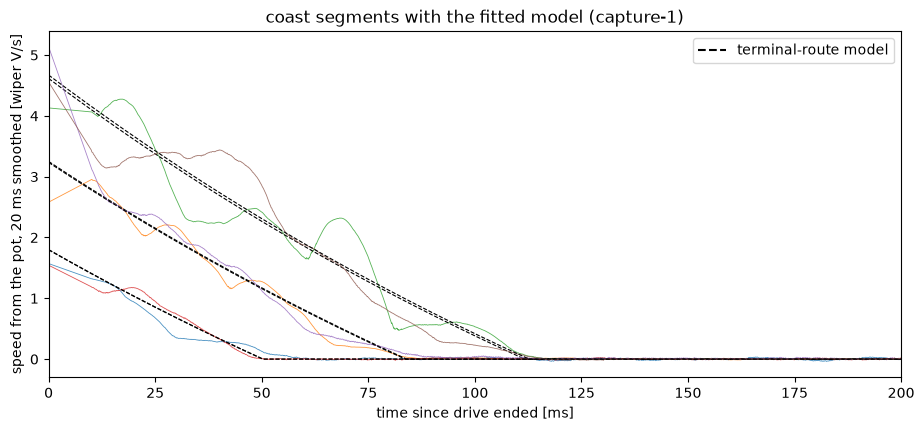

,pot route a [V/s2],pot route b [1/s],pot route rms resid [mV],terminal route a [V/s2],terminal route b [1/s],terminal route b se [1/s],terminal route rms resid [mV]
mean,40.41,0.59,2.36,31.64,4.44,0.07,30.53
min,36.70,0.00,2.22,30.81,4.22,0.07,30.17
max,42.12,2.94,2.51,32.49,4.58,0.07,31.07
count,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [12]:
FIT_N = 5000   # 250 ms of every zero-duty segment enters the fit

def traj(t, p0, v0, a, b):
    # Position under dv/dt = -(a + b v) from v0, at rest after t_stop.
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    tt = np.minimum(t, t_stop)
    return p0 + (v0 + a / b) * (1 - np.exp(-b * tt)) / b - (a / b) * tt

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def joint_fit(segs, signal, mask_fn, has_p0):
    # Shared (a, b), per-segment start value (and offset when has_p0).
    t = np.arange(FIT_N) / TICK_HZ
    per = 2 if has_p0 else 1
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            y = c[signal][:FIT_N]
            m = mask_fn(c)[:FIT_N]
            if has_p0:
                model = traj(t, x[2 + per * i], x[3 + per * i], x[0], x[1])
            else:
                model = speed_model(t, x[2 + i], x[0], x[1])
            r.append((model - y)[m])
        return np.concatenate(r)
    x0 = [30.0, 5.0]
    lb = [0.0, 0.0]
    for c in segs:
        y = c[signal]
        if has_p0:
            x0 += [y[0], 5.0]
            lb += [-np.inf, 0.0]
        else:
            x0 += [max(y[3], 0.1)]
            lb += [0.0]
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    se = np.sqrt(np.diag(cov))
    starts = res.x[3::2] if has_p0 else res.x[2:]
    return {"a": res.x[0], "b": res.x[1], "a_se": se[0], "b_se": se[1],
            "starts": starts, "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

coast_fits = {}
for name, sweeps in recs.items():
    segs = coast_segments(sweeps)
    slope = bemf_fit.loc[name, "slope_integral_s"]
    pot = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
    term = joint_fit(segs, "e", lambda c: coast_mask(c, rails[name]), False)
    coast_fits[name] = {"segs": segs, "pot": pot, "term": term, "slope": slope}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(coast_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    vm = speed_model(t, f["term"]["starts"][i], f["term"]["a"], f["term"]["b"]) / f["slope"]
    ax.plot(t * 1e3, vm, "k--", lw=0.8)
ax.plot([], [], "k--", label="terminal-route model")
ax.set_xlim(0, 200)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 20 ms smoothed [wiper V/s]")
ax.set_title(f"coast segments with the fitted model ({name})")
ax.legend()
plt.show()

rows = []
for name, f in coast_fits.items():
    rows.append({
        "recording": name,
        "pot route a [V/s2]": f["pot"]["a"],
        "pot route b [1/s]": f["pot"]["b"],
        "pot route rms resid [mV]": f["pot"]["rms_resid"] * 1e3,
        "terminal route a [V/s2]": f["term"]["a"] / f["slope"],
        "terminal route b [1/s]": f["term"]["b"],
        "terminal route b se [1/s]": f["term"]["b_se"],
        "terminal route rms resid [mV]": f["term"]["rms_resid"] * 1e3,
    })
coast_tab = pd.DataFrame(rows).set_index("recording")
coast_tab.agg(["mean", "min", "max", "count"]).round(2)

Findings:

- The terminal route puts the Coulomb term at 32 wiper V/s$^2$ (31 to 32
  across recordings) and the viscous term at 4.4 1/s (4.2 to 4.6). The
  standard error on $b$ from the fit is 0.07 1/s, an optimistic figure,
  since the 31 mV rms residual is dominated by the EMF ripple, which is
  correlated from sample to sample. At the highest entry speed of about
  4.6 wiper V/s the viscous term contributes 20 wiper V/s$^2$, two
  thirds of the Coulomb term, so the model curves in the figure are
  close to straight lines.
- The retired run put the split at 34 and 3.0. The total deceleration at
  3 wiper V/s comes out at 45 wiper V/s$^2$ here and 43 there, so the
  two runs agree within a few percent on how fast the mechanism slows
  down and disagree on the split between the two terms. Friction has no
  rail in it, so this is not the supply as such. The speed range here is
  half the old one, which leaves the split less constrained, and the two
  runs are separate sessions of a worn gear train. Which of these it is,
  I cannot tell from this data.
- The pot route puts the Coulomb term at 40 wiper V/s$^2$ (37 to 42) and
  drives $b$ to 0.6 1/s (0 to 2.9). The pot ripple is larger than the
  curvature that separates the two terms over a single segment, so the
  pot route cannot resolve the split. Its Coulomb term is within 3% of
  the retired run's 39, for what a term fitted with $b$ pinned at zero
  is worth.
- The two routes agree on the average deceleration over a segment and
  disagree on its split. Section 6.4 tests the terminal-route parameters
  against the measured stopping distances, which the pot measures without
  ripple sensitivity.

### 6.3 Brake deceleration vs speed

In brake the winding is shorted through the low-side switches. The
back-EMF drives a current through the winding resistance and the switch
on-resistance, and the resulting torque opposes the motion in proportion
to speed, so the same model applies with a much larger $b$. The terminals
are within 0.02 V of ground during brake (section 5.4), so no EMF is
readable and only the pot route is available. The friction is the same
mechanism as in coast, so the fit first holds $a$ at the terminal-route
coast value of the same recording and fits $b$ and the entry speeds, then
repeats with $a$ free as a check.

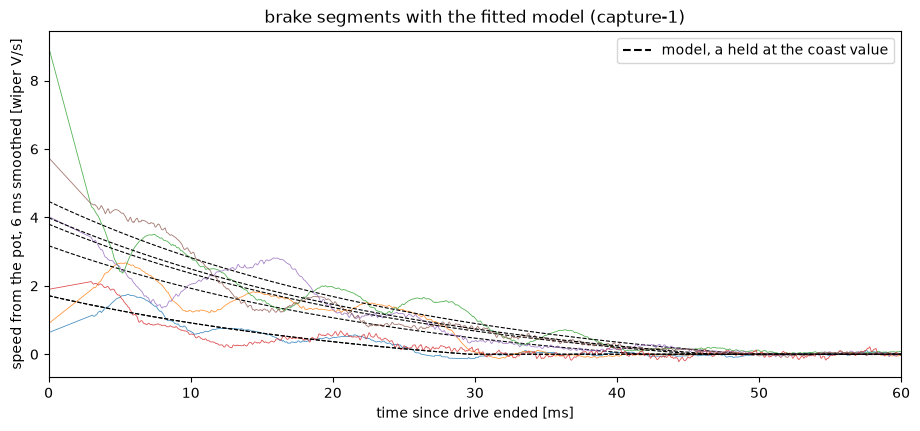

,a held [V/s2],"b, a held [1/s]",b se [1/s],"rms resid, a held [mV]",a free [V/s2],"b, a free [1/s]","rms resid, a free [mV]",brake/coast b ratio
mean,31.64,35.13,0.18,1.66,38.89,29.18,1.66,7.93
min,30.81,32.03,0.17,1.43,30.51,18.29,1.43,7.31
max,32.49,36.84,0.21,1.86,50.42,38.10,1.85,8.57
count,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [13]:
def brake_segments(sweeps):
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "brake"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vA, vB = terms_V(seg)
        out.append({
            "seg": seg_id,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "t": np.arange(len(seg)) / TICK_HZ,
            "p": seg["pos"].to_numpy() * d * CH.v_adc_per_count,
            "vA": vA,
            "vB": vB,
        })
    return out

def brake_fit_fixed_a(segs, a_fixed):
    t = np.arange(FIT_N) / TICK_HZ
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            r.append(traj(t, x[1 + 2 * i], x[2 + 2 * i], a_fixed, x[0]) - c["p"][:FIT_N])
        return np.concatenate(r)
    x0 = [40.0] + sum([[c["p"][0], 5.0] for c in segs], [])
    lb = [0.0] + sum([[-np.inf, 0.0] for _ in segs], [])
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    return {"b": res.x[0], "b_se": np.sqrt(cov[0, 0]), "starts": res.x[2::2],
            "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

brake_fits = {}
for name, sweeps in recs.items():
    segs = brake_segments(sweeps)
    a_coast = coast_fits[name]["term"]["a"] / coast_fits[name]["slope"]
    fixed = brake_fit_fixed_a(segs, a_coast)
    free = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
    brake_fits[name] = {"segs": segs, "fixed": fixed, "free": free, "a_coast": a_coast}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(brake_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], 121, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    ax.plot(t * 1e3, speed_model(t, f["fixed"]["starts"][i], f["a_coast"], f["fixed"]["b"]),
            "k--", lw=0.8)
ax.plot([], [], "k--", label="model, a held at the coast value")
ax.set_xlim(0, 60)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 6 ms smoothed [wiper V/s]")
ax.set_title(f"brake segments with the fitted model ({name})")
ax.legend()
plt.show()

rows = []
for name, f in brake_fits.items():
    b_coast = coast_fits[name]["term"]["b"]
    rows.append({
        "recording": name,
        "a held [V/s2]": f["a_coast"],
        "b, a held [1/s]": f["fixed"]["b"],
        "b se [1/s]": f["fixed"]["b_se"],
        "rms resid, a held [mV]": f["fixed"]["rms_resid"] * 1e3,
        "a free [V/s2]": f["free"]["a"],
        "b, a free [1/s]": f["free"]["b"],
        "rms resid, a free [mV]": f["free"]["rms_resid"] * 1e3,
        "brake/coast b ratio": f["fixed"]["b"] / b_coast,
    })
brake_tab = pd.DataFrame(rows).set_index("recording")
brake_tab.agg(["mean", "min", "max", "count"]).round(2)

Findings:

- With $a$ held at the coast value, the brake viscous term is 35 1/s (32
  to 37 across recordings), 7 to 9 times the coast value. The winding
  short adds electrical damping of that size on top of the mechanical
  friction. The retired run gave 43 (35 to 51), 12 to 18 times its
  smaller coast $b$. The electrical damping has no rail in it, and the
  27 mOhm the larger shunt adds to a winding loop of a few ohms is under
  1%, so neither the supply nor the chain explains the drop. It sits at
  the low end of the old scatter, and the held $a$ is 8% smaller here,
  which the fit makes up with $b$. I leave it open.
- Freeing $a$ lets the two terms trade against each other over a wide
  range ($a$ from 31 to 50 wiper V/s$^2$, $b$ from 18 to 38 1/s) with
  no change in residual, the same trade-off seen in the pot route of
  section 6.2. The pot ripple sets this limit, and the brake segments
  are too short (28 to 54 ms) for the curvature to override it.
- The model misses the first few milliseconds of the fastest entries,
  where the measured speed drops faster than the fitted exponential. The
  ripple period at those speeds is close to the fit's time scale, so
  whether this is a real departure from the linear model is left open.

### 6.4 Stopping distance vs entry speed

For the fitted model the stopping distance from entry speed $v_0$ is

$$d(v_0) = \frac{v_0}{b} - \frac{a}{b^2}\ln\!\left(1 + \frac{b\,v_0}{a}\right).$$

The measured stopping distance of each zero-duty segment is the settled
position (median of the last 50 ms) minus the position at entry. The entry
speed comes from the fits above (the terminal route for coast, the held-a
fit for brake). The figure compares measured distances with the model
curve for both states, which is a check of the fitted parameters against
a quantity the pot measures without ripple sensitivity.

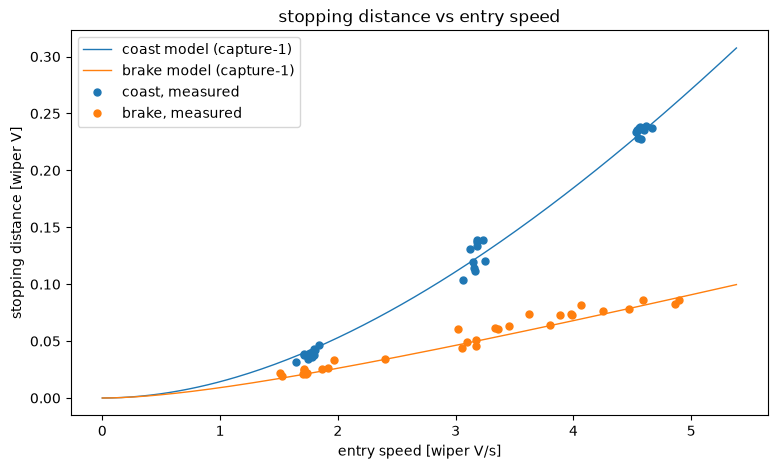

state             brake                   coast                 
entry_pct            20      30      40      20      30       40
entry_Vps  min    1.513   2.398   3.624   1.647   3.062    4.534
           max    1.968   3.803   4.895   1.841   3.251    4.671
           mean   1.740   3.187   4.261   1.761   3.168    4.574
measured_V min    0.019   0.034   0.073   0.031   0.104    0.227
           max    0.033   0.064   0.086   0.047   0.139    0.239
           mean   0.024   0.053   0.078   0.039   0.125    0.235
model_V    min    0.018   0.037   0.066   0.037   0.116    0.230
           max    0.028   0.064   0.091   0.046   0.128    0.241
           mean   0.022   0.052   0.077   0.042   0.123    0.234
error_pct  min  -16.813 -15.488 -12.256  -1.332 -10.337   -1.967
           max    2.787   9.955   7.260  23.729  11.725    2.534
           mean  -8.008  -1.442  -2.653   9.910  -0.466   -0.104
stop_ms    min   28.288  38.418  46.752  46.800  80.561  109.699
           max   34.182  45.711  53.993  52.157  84.540  112.806
           mean  30.601  42.919  49.632  49.749  82.863  111.711

In [14]:
def stop_dist(v0, a, b):
    return v0 / b - a / b ** 2 * np.log1p(b * v0 / a)

rows = []
for name in recs:
    cf, bf = coast_fits[name], brake_fits[name]
    for i, c in enumerate(cf["segs"]):
        v0 = cf["term"]["starts"][i] / cf["slope"]
        a, b = cf["term"]["a"] / cf["slope"], cf["term"]["b"]
        rows.append({"recording": name, "state": "coast", "entry_pct": c["entry_pct"],
                     "entry_Vps": v0,
                     "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                     "model_V": stop_dist(v0, a, b),
                     "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
    for i, c in enumerate(bf["segs"]):
        v0 = bf["fixed"]["starts"][i]
        a, b = bf["a_coast"], bf["fixed"]["b"]
        rows.append({"recording": name, "state": "brake", "entry_pct": c["entry_pct"],
                     "entry_Vps": v0,
                     "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                     "model_V": stop_dist(v0, a, b),
                     "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
sd = pd.DataFrame(rows)
sd["error_pct"] = (sd["model_V"] / sd["measured_V"] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
vv = np.linspace(0, sd["entry_Vps"].max() * 1.1, 200)
name = next(iter(recs))
cf, bf = coast_fits[name], brake_fits[name]
ax.plot(vv, stop_dist(vv, cf["term"]["a"] / cf["slope"], cf["term"]["b"]), "-",
        color="tab:blue", lw=1, label=f"coast model ({name})")
ax.plot(vv, stop_dist(vv, bf["a_coast"], bf["fixed"]["b"]), "-",
        color="tab:orange", lw=1, label=f"brake model ({name})")
for state, color in [("coast", "tab:blue"), ("brake", "tab:orange")]:
    g = sd[sd["state"] == state]
    ax.plot(g["entry_Vps"], g["measured_V"], "o", color=color, ms=5, label=f"{state}, measured")
ax.set_xlabel("entry speed [wiper V/s]")
ax.set_ylabel("stopping distance [wiper V]")
ax.set_title("stopping distance vs entry speed")
ax.legend()
plt.show()

(sd.groupby(["state", "entry_pct"])[["entry_Vps", "measured_V", "model_V", "error_pct", "stop_ms"]]
   .agg(["min", "max", "mean"]).round(3).T)

Findings:

- Coast stopping distances range from 0.03 to 0.24 wiper V for entry
  speeds of 1.6 to 4.7 wiper V/s, with stop times of 47 to 113 ms. The
  terminal-route model matches the measured distances within 12% at the
  30% and 40% entries (mean error under 1%) and within 24% at the 20%
  entries (mean +10%), where the travel is under one ripple period and
  the Coulomb term dominates. The agreement at the 30% and 40% entries
  supports the split between the Coulomb and viscous terms that the pot
  route could not resolve. At the 20% entries the model over-predicts,
  the opposite sign to the retired run, which under-predicted by 5%
  there. A model that stops too late at low speed has its Coulomb term
  a little low, so the split of section 6.2 leans too far toward viscous
  near rest. Notebook 04 takes that up.
- Brake stopping distances are two and a half to three times shorter at
  the same entry speed, 0.02 to 0.09 wiper V, with stop times of 28 to
  54 ms. The held-$a$ model matches them within 17%, the scatter the pot
  ripple leaves on segments this short.

## 7. Limitations and open issues

- **One unit, one supply.** All numbers describe this one servo on a
  laptop USB port whose rail sags 0.3 V across the duty range. The gear
  train has prior wear.
- **The board is a hacked rig.** Section 1 describes it. The bus
  telemetry stream couples into the current amplifier output on this
  board. It is flat within about a count at rest on this firmware build
  (notebook 00, section 5.2), but it is a limitation of the board, and I
  leave it as one. The next board revision does not have it, and nothing
  in this notebook is written to dodge it.
- **Rail-dependent numbers.** The speeds, the travel, the EMF magnitudes,
  the freewheel current, the fast-decay motion threshold and how far the
  floating terminals get toward their clamps all scale with the rail,
  and they are all smaller here than in the retired battery run. The
  slopes, the on-resistances, the friction terms and the brake damping
  should not depend on it.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per sweep and per terminal, 0.617 V on A and 0.632 V on B
  against a nominal 0.628 V, so the absolute terminal voltages inherit
  only the VDD scaling. The nominal bias divider itself is a design
  value with unmeasured tolerance.
- **The two terminals do not read alike.** Their rest readings differ by
  18 counts (notebook 00, section 5.3), and after each is corrected with
  its own rest reading they still differ by about 40 mV when driven and
  80 mV on the low side, with different low-side slopes (section 5.2).
  Using each terminal's own rest reading is the whole treatment here.
  The cause is open.
- **Coast from high speed is absent.** The schedule stops at 40% duty,
  kept from the battery run where the runway limited it. At this rail
  the 40% entry reaches only 4.7 wiper V/s, under half the top speed of
  notebook 00, so the coast model is fitted below that and extrapolated
  above. A spin-down capture with 60% and 80% entries would fix that at
  this supply.
- **Entry speeds vary.** Each drive step starts with residual motion from
  the repositioning move, so the entry speeds are measured, never
  commanded, and the spin-down segments do not pair up.
- **The pot speed ripple.** The pot-derived speed carries a ripple of 10
  to 20% rms that the EMF does not show (section 6.1). Every fit that
  uses the pot alone is limited by it, in particular the split between
  Coulomb and viscous friction in section 6.2 and the whole of section
  6.3. At this rail the 20% coast entries travel less than one ripple
  period, which is why their integral ratios are all over the place.
- **The clamp and diode levels are measured levels.** The diode-phase
  levels (rail plus 0.86 V on one terminal, -0.52 V on the other) are
  read from this driver at these currents. In coast the negative
  terminal carries nearly the whole EMF and only just reaches its
  body-diode clamp at -0.41 V at the highest EMF here (section 6.1), and
  the asymmetric split is a hypothesis. They enter the validity map as
  state checks. The EMF is independent of them, since it is the terminal
  difference.
- **OFF-state shunt samples sit 5 counts above the baseline.** The
  trough scan under slow decay, the crest scan under fast decay, and the
  spin-down brake and coast segments all read 4 to 5 counts above the
  bridge-disabled baseline (section 5.2), and the trough offset then
  grows with duty far faster than on the retired chain, past 20 counts
  at 65%. Both are open.
- **The fast-decay coast reading is unexplained.** Section 5.3 shows what
  the crest-scan terminals read in the 40% to 50% range and rules out
  back-EMF. The mechanism behind the reading is a hypothesis.
- **The sampling floors are this board's.** The 13.3% and 10.0% floors
  and the scan slot offsets change with board revision and firmware
  configuration.

## 8. What the next notebooks use from here

- The validity map of section 5.4, as the gate on every current and
  terminal sample by bridge state, decay mode and scan.
- The tap formula of section 2, $V_t = r\,\text{tap} - (r - 1) V_B$ with
  $V_B$ read from the baseline of each sweep for each terminal
  separately, for every absolute terminal voltage, and the difference
  $v_A - v_B$ on the same per-terminal correction for the EMF.
- The rail, the diode level and the discriminator threshold of section
  5.3, all in corrected terminal volts, for separating the diode phase
  from the settled coast window, with the sum's rest level at
  $V_{B,A} + V_{B,B}$.
- The coast EMF $v_A - v_B$ as a direct speed signal with the slope of
  section 6.1 (0.274 V per wiper V/s on this chain), and the fact that
  the pot ripple is absent from it.
- The coast friction model of section 6.2 (Coulomb 32 wiper V/s$^2$ by
  the terminal route and 40 by the pot route, viscous 4.4 1/s by the
  terminal route) and the brake damping of section 6.3 (about 35 1/s),
  as inputs to the friction and inertia notebooks, with the caveat that
  the split moved against the retired run while the total did not.
- The 5-count offset of every OFF-state shunt sample above the
  bridge-disabled baseline, for whatever tracks the bias live.
- The rule that direct back-EMF comes from coast segments, since the
  fast-decay crest scan does not deliver it in this scan geometry.